In [11]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import torch

# Load original (large) tif data files

In [12]:
# Path to your .tif file (single-band tif)
tif_path_image = '/Users/kimbente/Desktop/MODIS_MOA/moa750_2014_hp1_v01.tif'
tif_path_hr_image = '/Users/kimbente/Desktop/MODIS_MOA/125/moa125_2014_hp1_v01.tif'
tif_path_grainsize = '/Users/kimbente/Desktop/MODIS_MOA/moa750_2014_grn_v01.tif'

# Open the .tif file
# takes a few seconds to load
with rasterio.open(tif_path_image) as src:
    # Read the data (for single-band TIFs, read the first band)
    image = src.read(1) 

with rasterio.open(tif_path_hr_image) as src:
    # Read the data (for single-band TIFs, read the first band)
    image_hr = src.read(1)

with rasterio.open(tif_path_grainsize) as src:
    # Read the data (for single-band TIFs, read the first band)
    grainsize = src.read(1)

Warning 1: TIFFReadDirectory:Invalid data type for tag StripByteCounts
Warning 1: TIFFFetchNormalTag:Incorrect value for "GeoKeyDirectory"; tag ignored
Warning 1: TIFFFetchNormalTag:ASCII value for tag "GeoASCIIParams" contains null byte in value; value incorrectly truncated during reading due to implementation limitations


In [13]:
print(image.shape)
print(image_hr.shape)
print(grainsize.shape)

print()
print(image.max())
print(image_hr.max())
print(grainsize.max())
# Different scales

(6964, 8056)
(41779, 48333)
(6964, 8056)

48455
56892
1105


# Export to .pt

Smaller size

In [ ]:
image_float = image.astype(float)
torch.save(torch.tensor(image_float), 'data/moa750_2014_hp1_v01.pt')

image_hr_float = image_hr.astype(float)
torch.save(torch.tensor(image_hr_float), 'data/moa125_2014_hp1_v01.pt')

grainsize_float = grainsize.astype(float)
torch.save(torch.tensor(grainsize_float), 'data/moa750_2014_grn_v01.pt')

# Grainsize

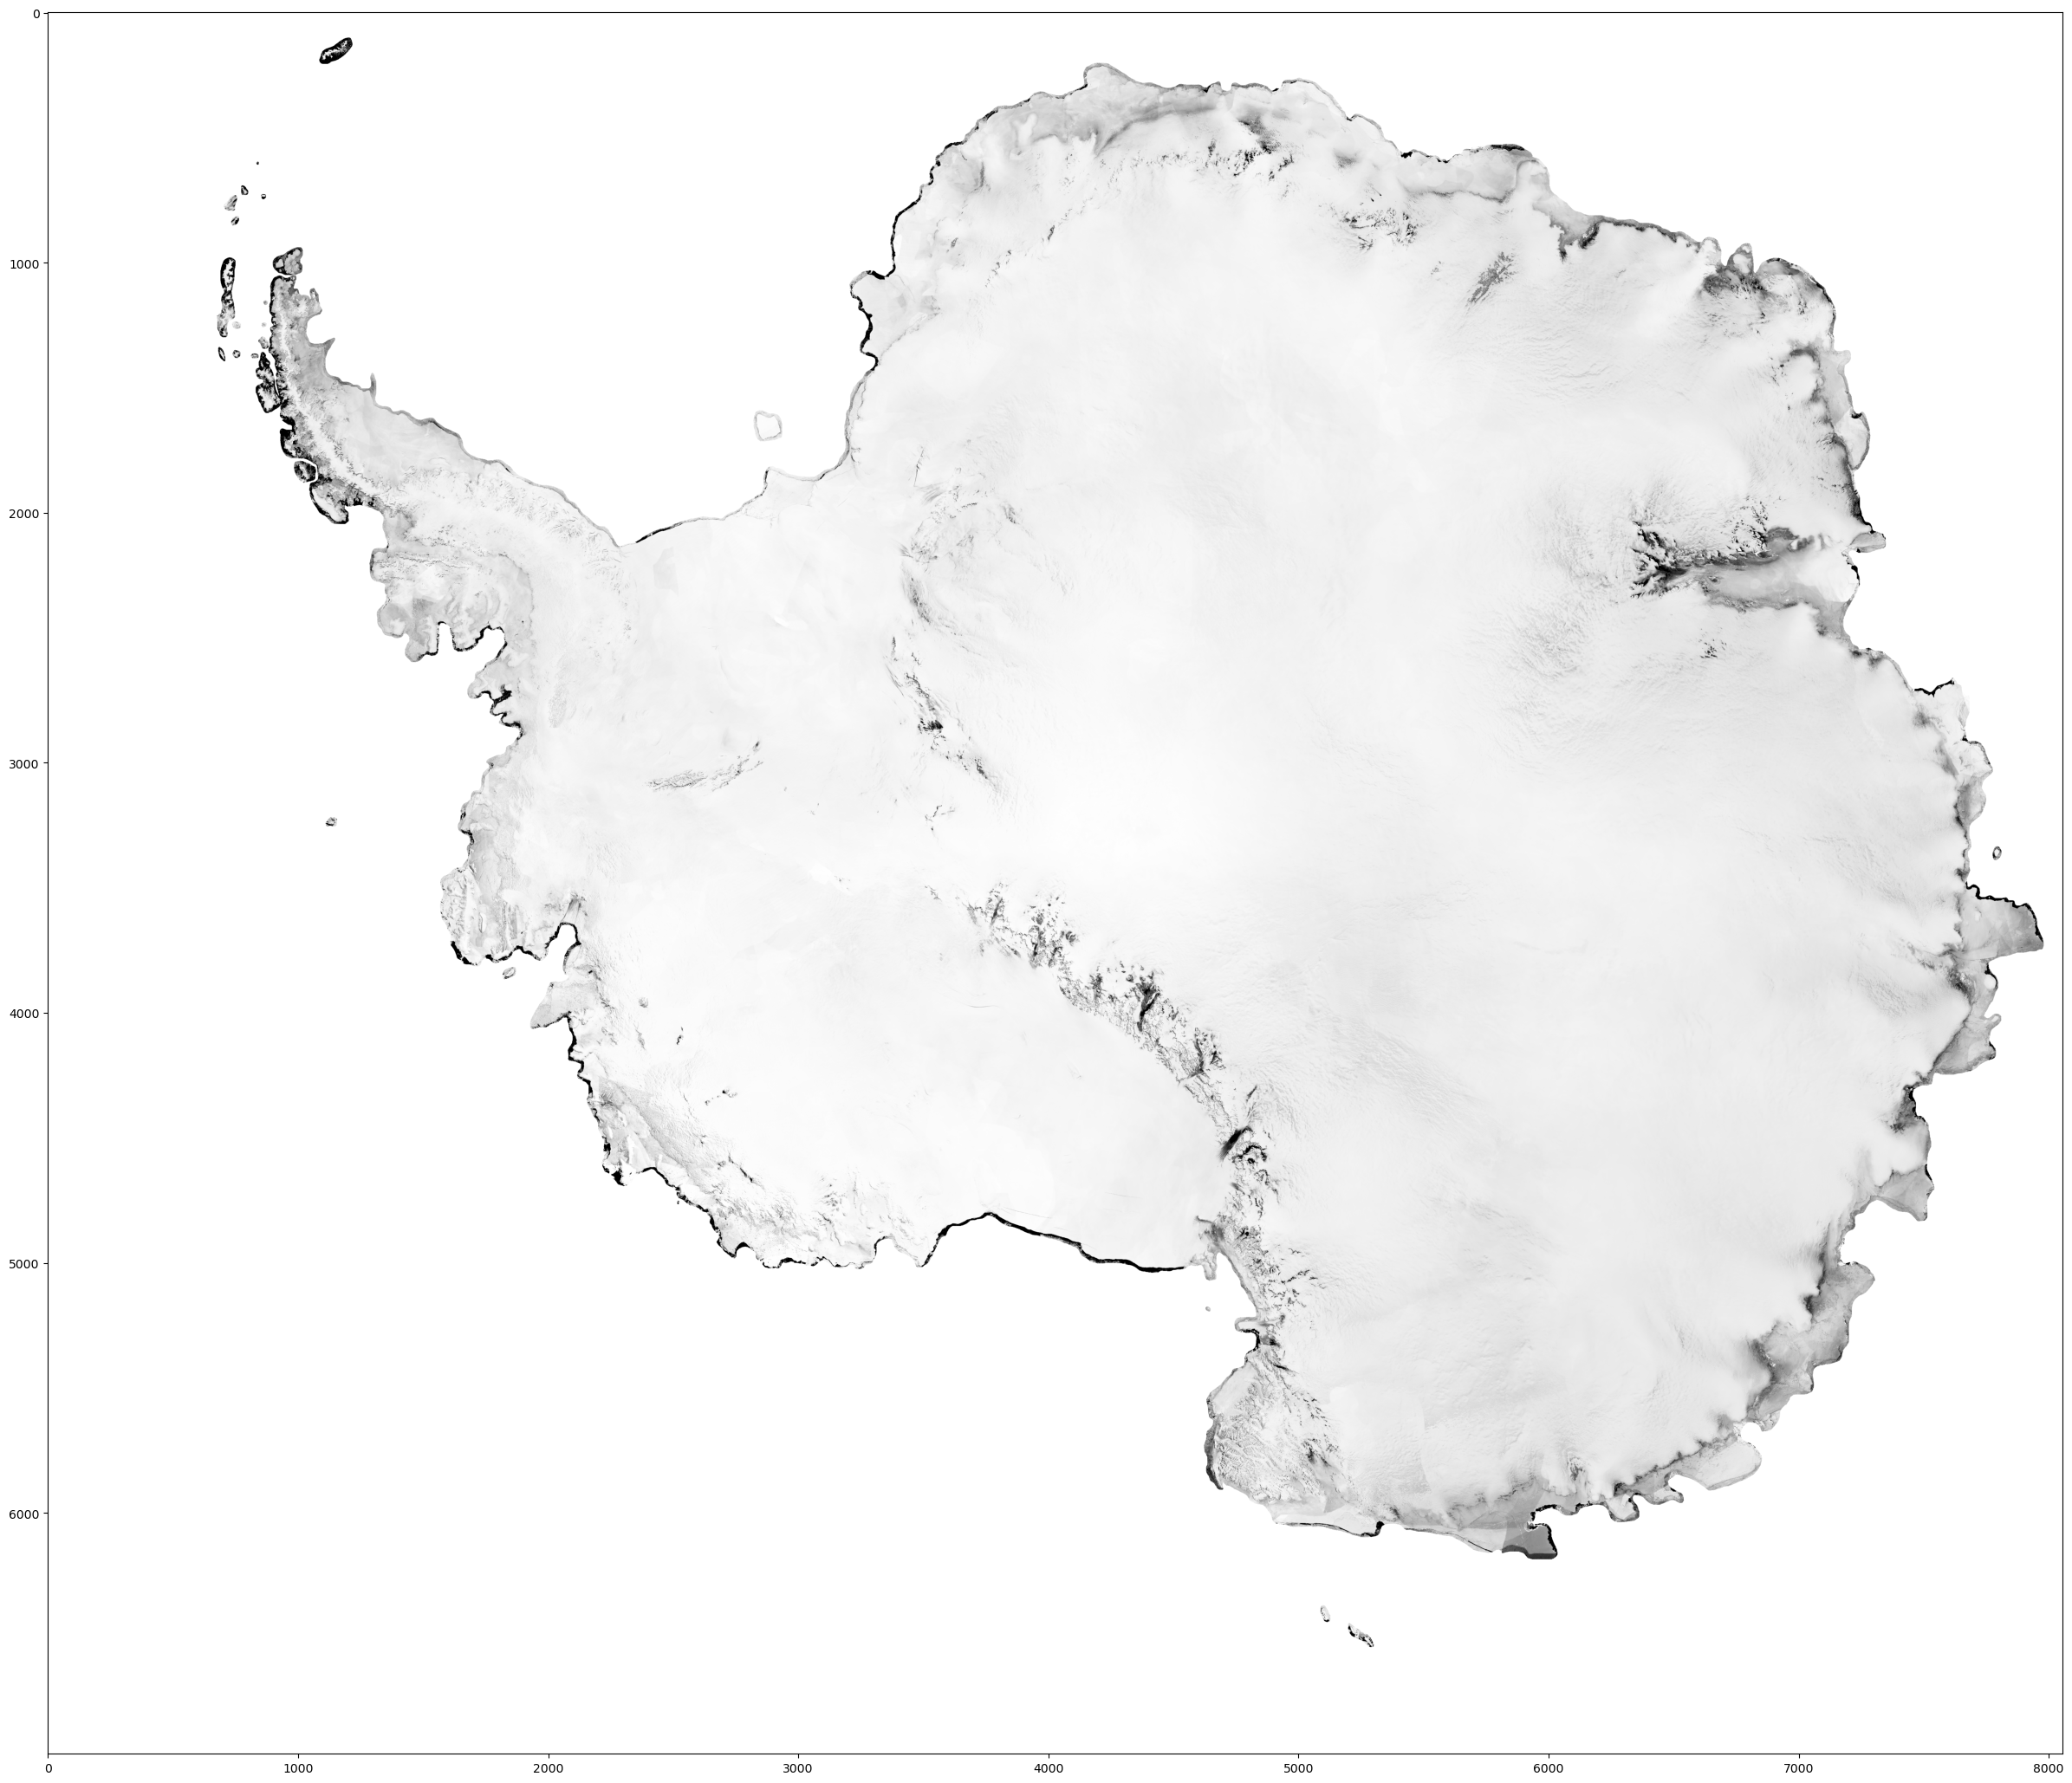

In [24]:
plt.figure(figsize = (30, 30))
plt.imshow(grainsize, cmap = 'gray_r')

# Image

In [40]:
image_na = image.copy().astype(float)
image_na[image_na == 0.0] = np.nan

In [52]:
image_na
np.nanmax(image_na)
np.nanmin(image_na)

522.0

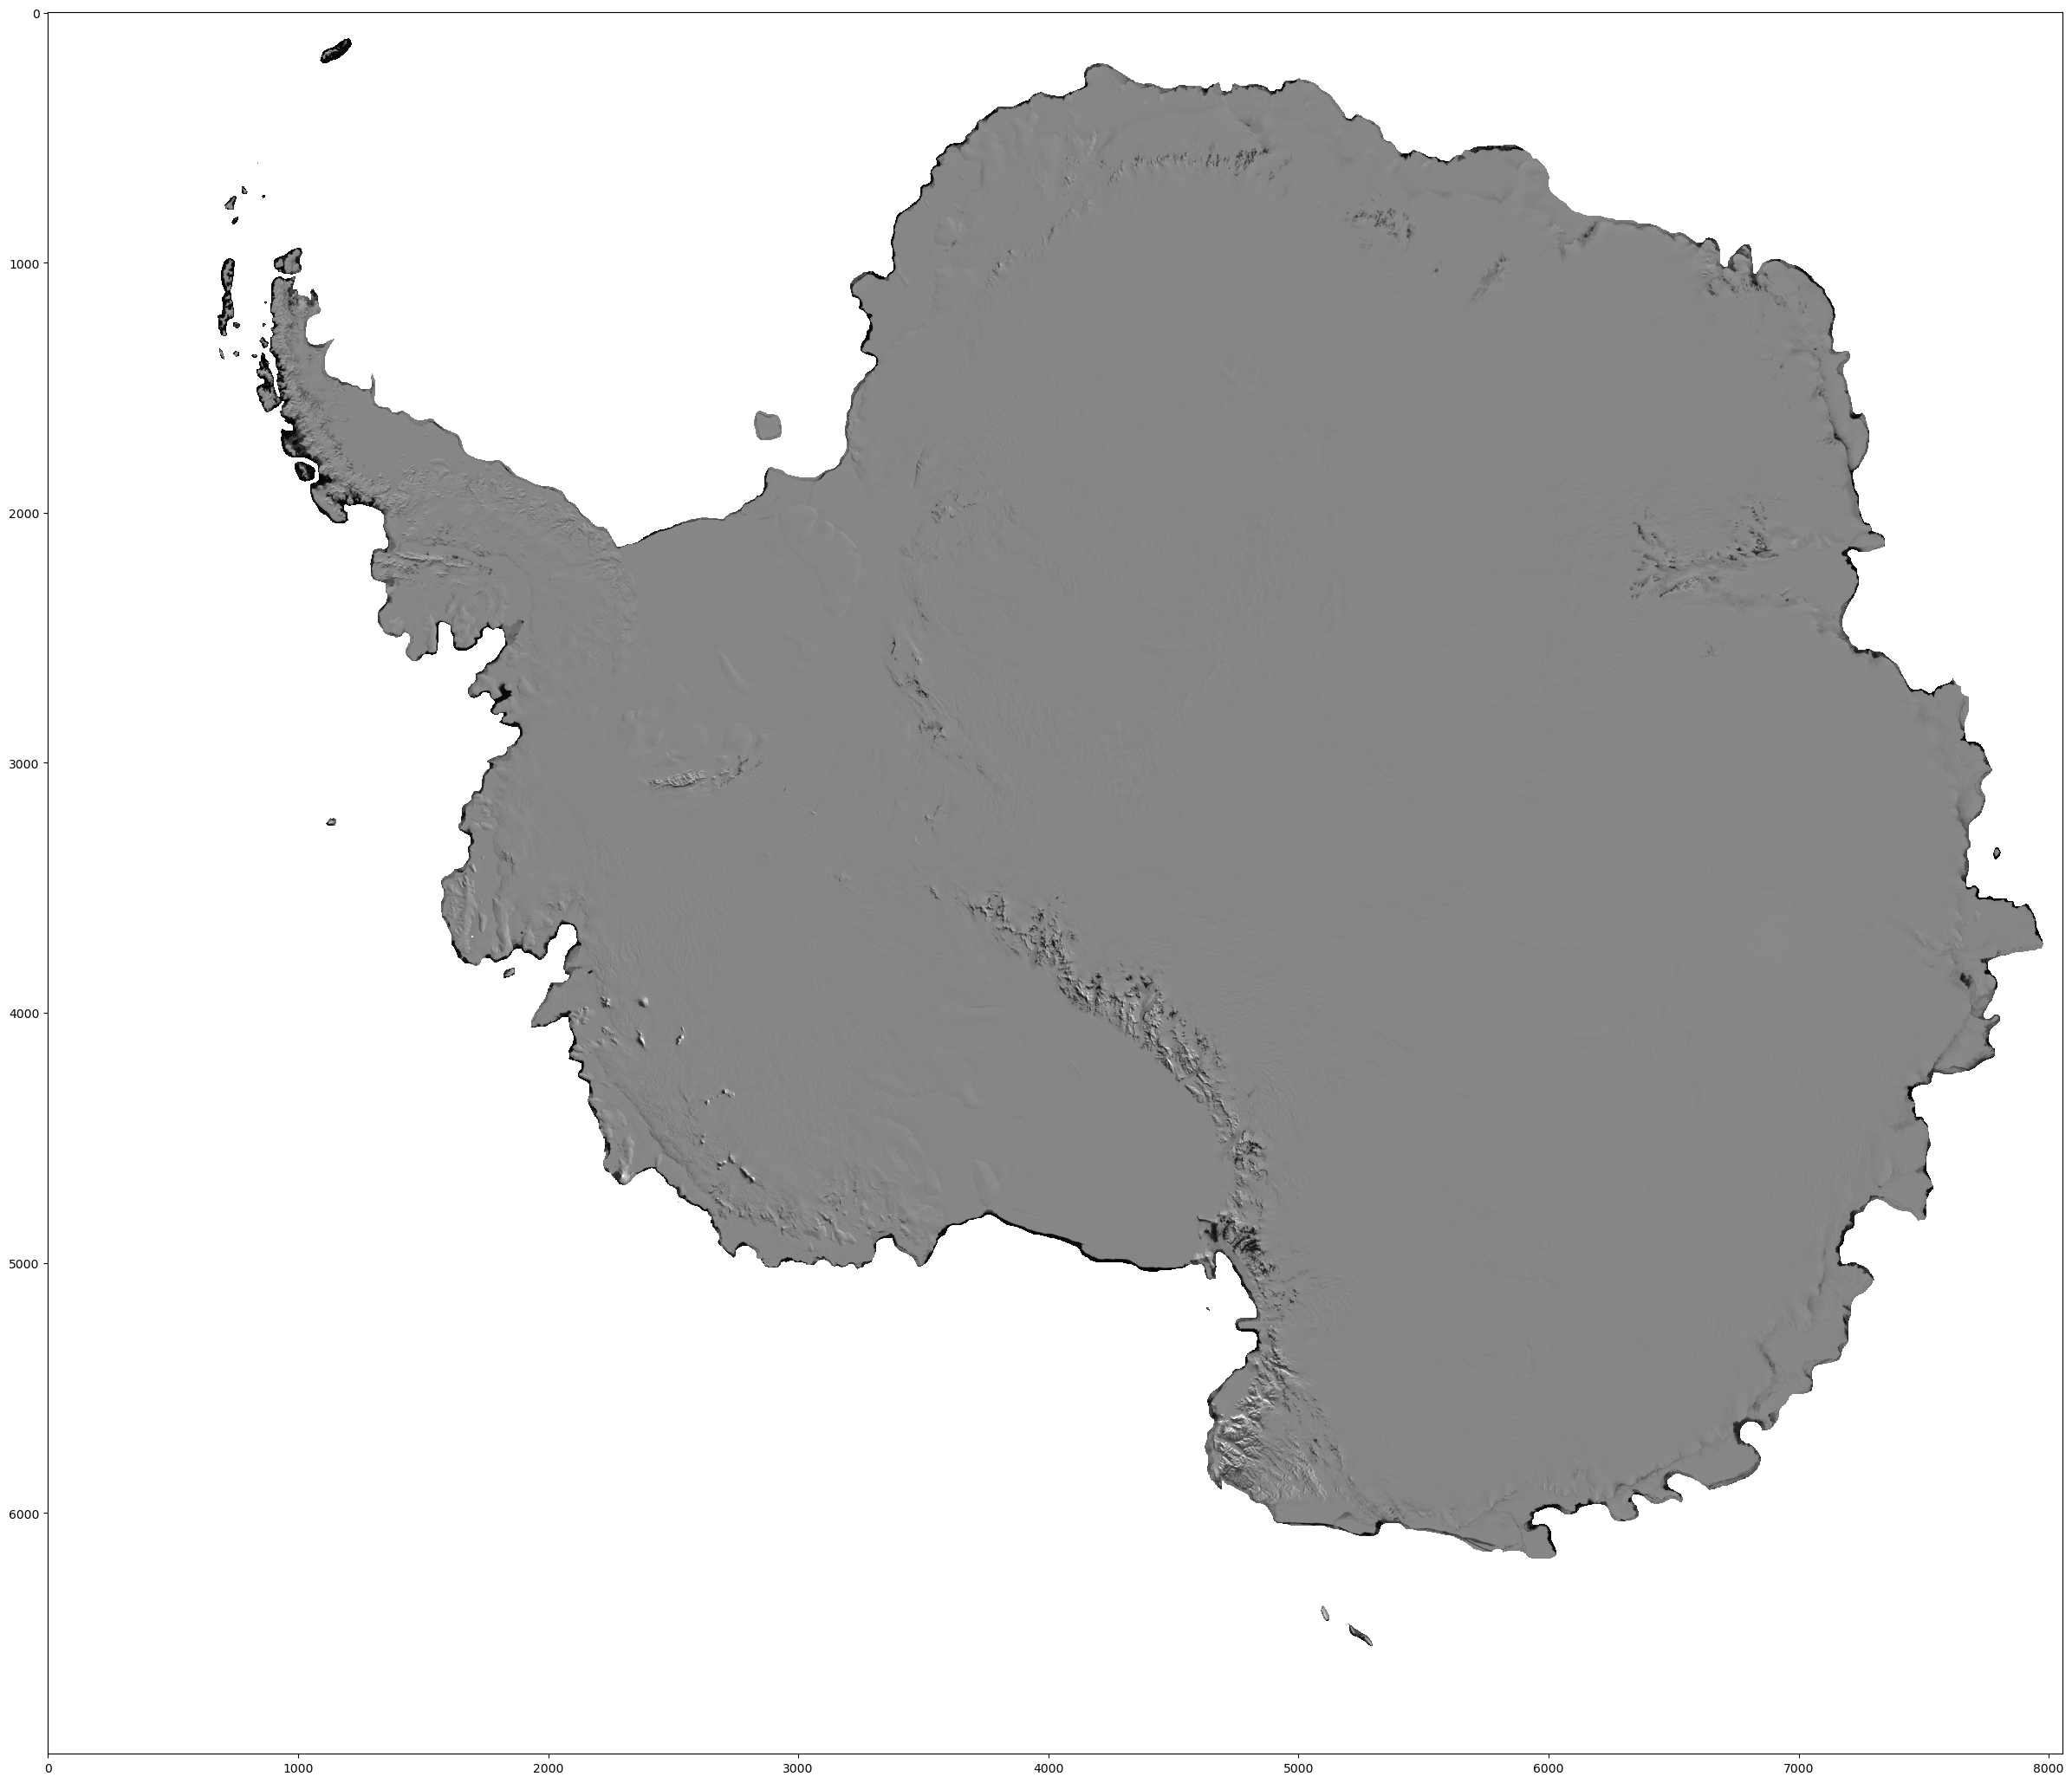

In [53]:
plt.figure(figsize = (30, 30))
# Not reversing this one
plt.imshow(image_na, cmap = 'binary_r', vmin = 500, vmax = 30000)

# Subset region

[Frome the documentation](https://nsidc.org/sites/default/files/nsidc-0730-v001-userguide.pdf) we can tell that

- 3,174,450 m is the x-axis map coordinate of the center of the upper-left pixel.
- 2,406,325 m is the y-axis map coordinate of the center of the upper-left pixel.

Our Byrd region is [350000.0 to 549500.0] and [-800500.0 to -1000000.0]

In [56]:
# x-axis
x_min = int((3174450 - - 350000)/750)
print(x_min)
x_max = int((3174450 - - 549500)/750)
print(x_max)

# y-axis (first term)
y_min = int((2406325 - - 800500)/750)
print(y_min)
y_max = int((2406325 - - 1000000)/750)
print(y_max)

4699
4965
4275
4541


# Repeat for high resolution

In [99]:
# x-axis
x_min_125 = int((3174450 - - 350000)/125)
print(x_min_125)
x_max_125 = int((3174450 - - 549500)/125)
print(x_max_125)

# y-axis (first term)
y_min_125 = int((2406325 - - 800500)/125)
print(y_min_125)
y_max_125 = int((2406325 - - 1000000)/125)
print(y_max_125)

28195
29791
25654
27250


## Grainsize

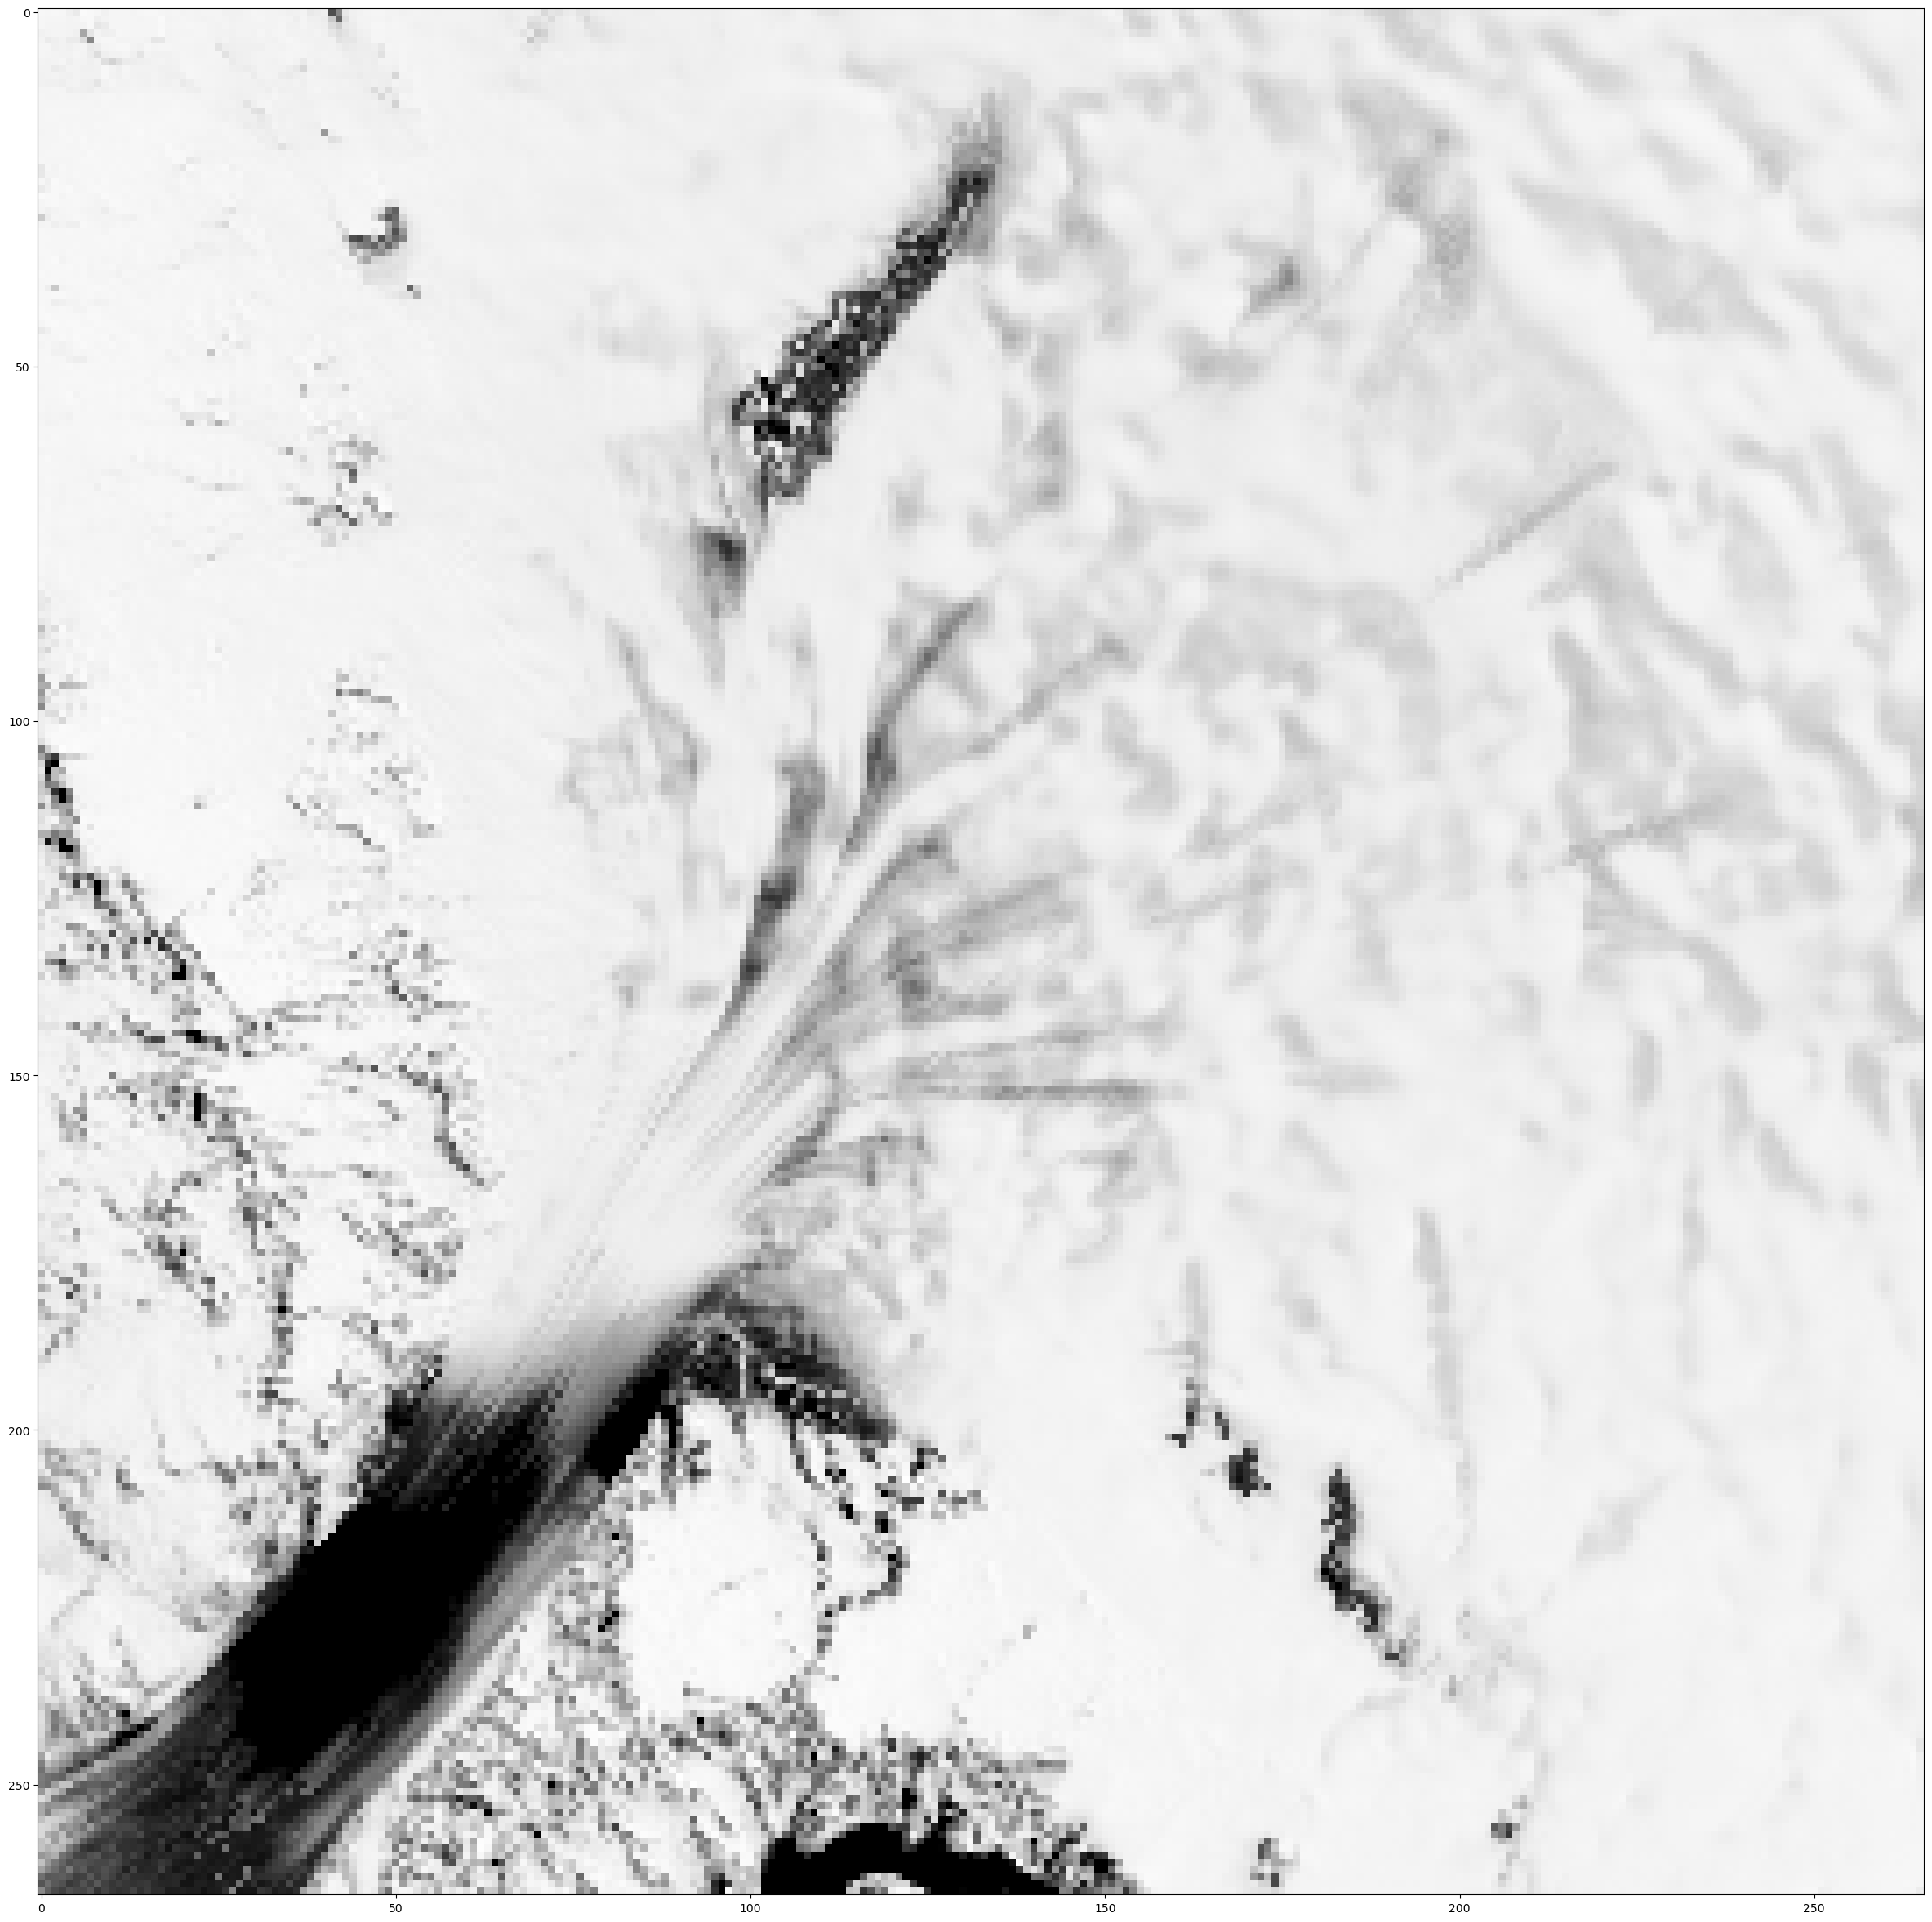

In [57]:
plt.figure(figsize = (30, 30))
plt.imshow(grainsize[y_min:y_max, x_min:x_max], cmap = 'gray_r')

## Image

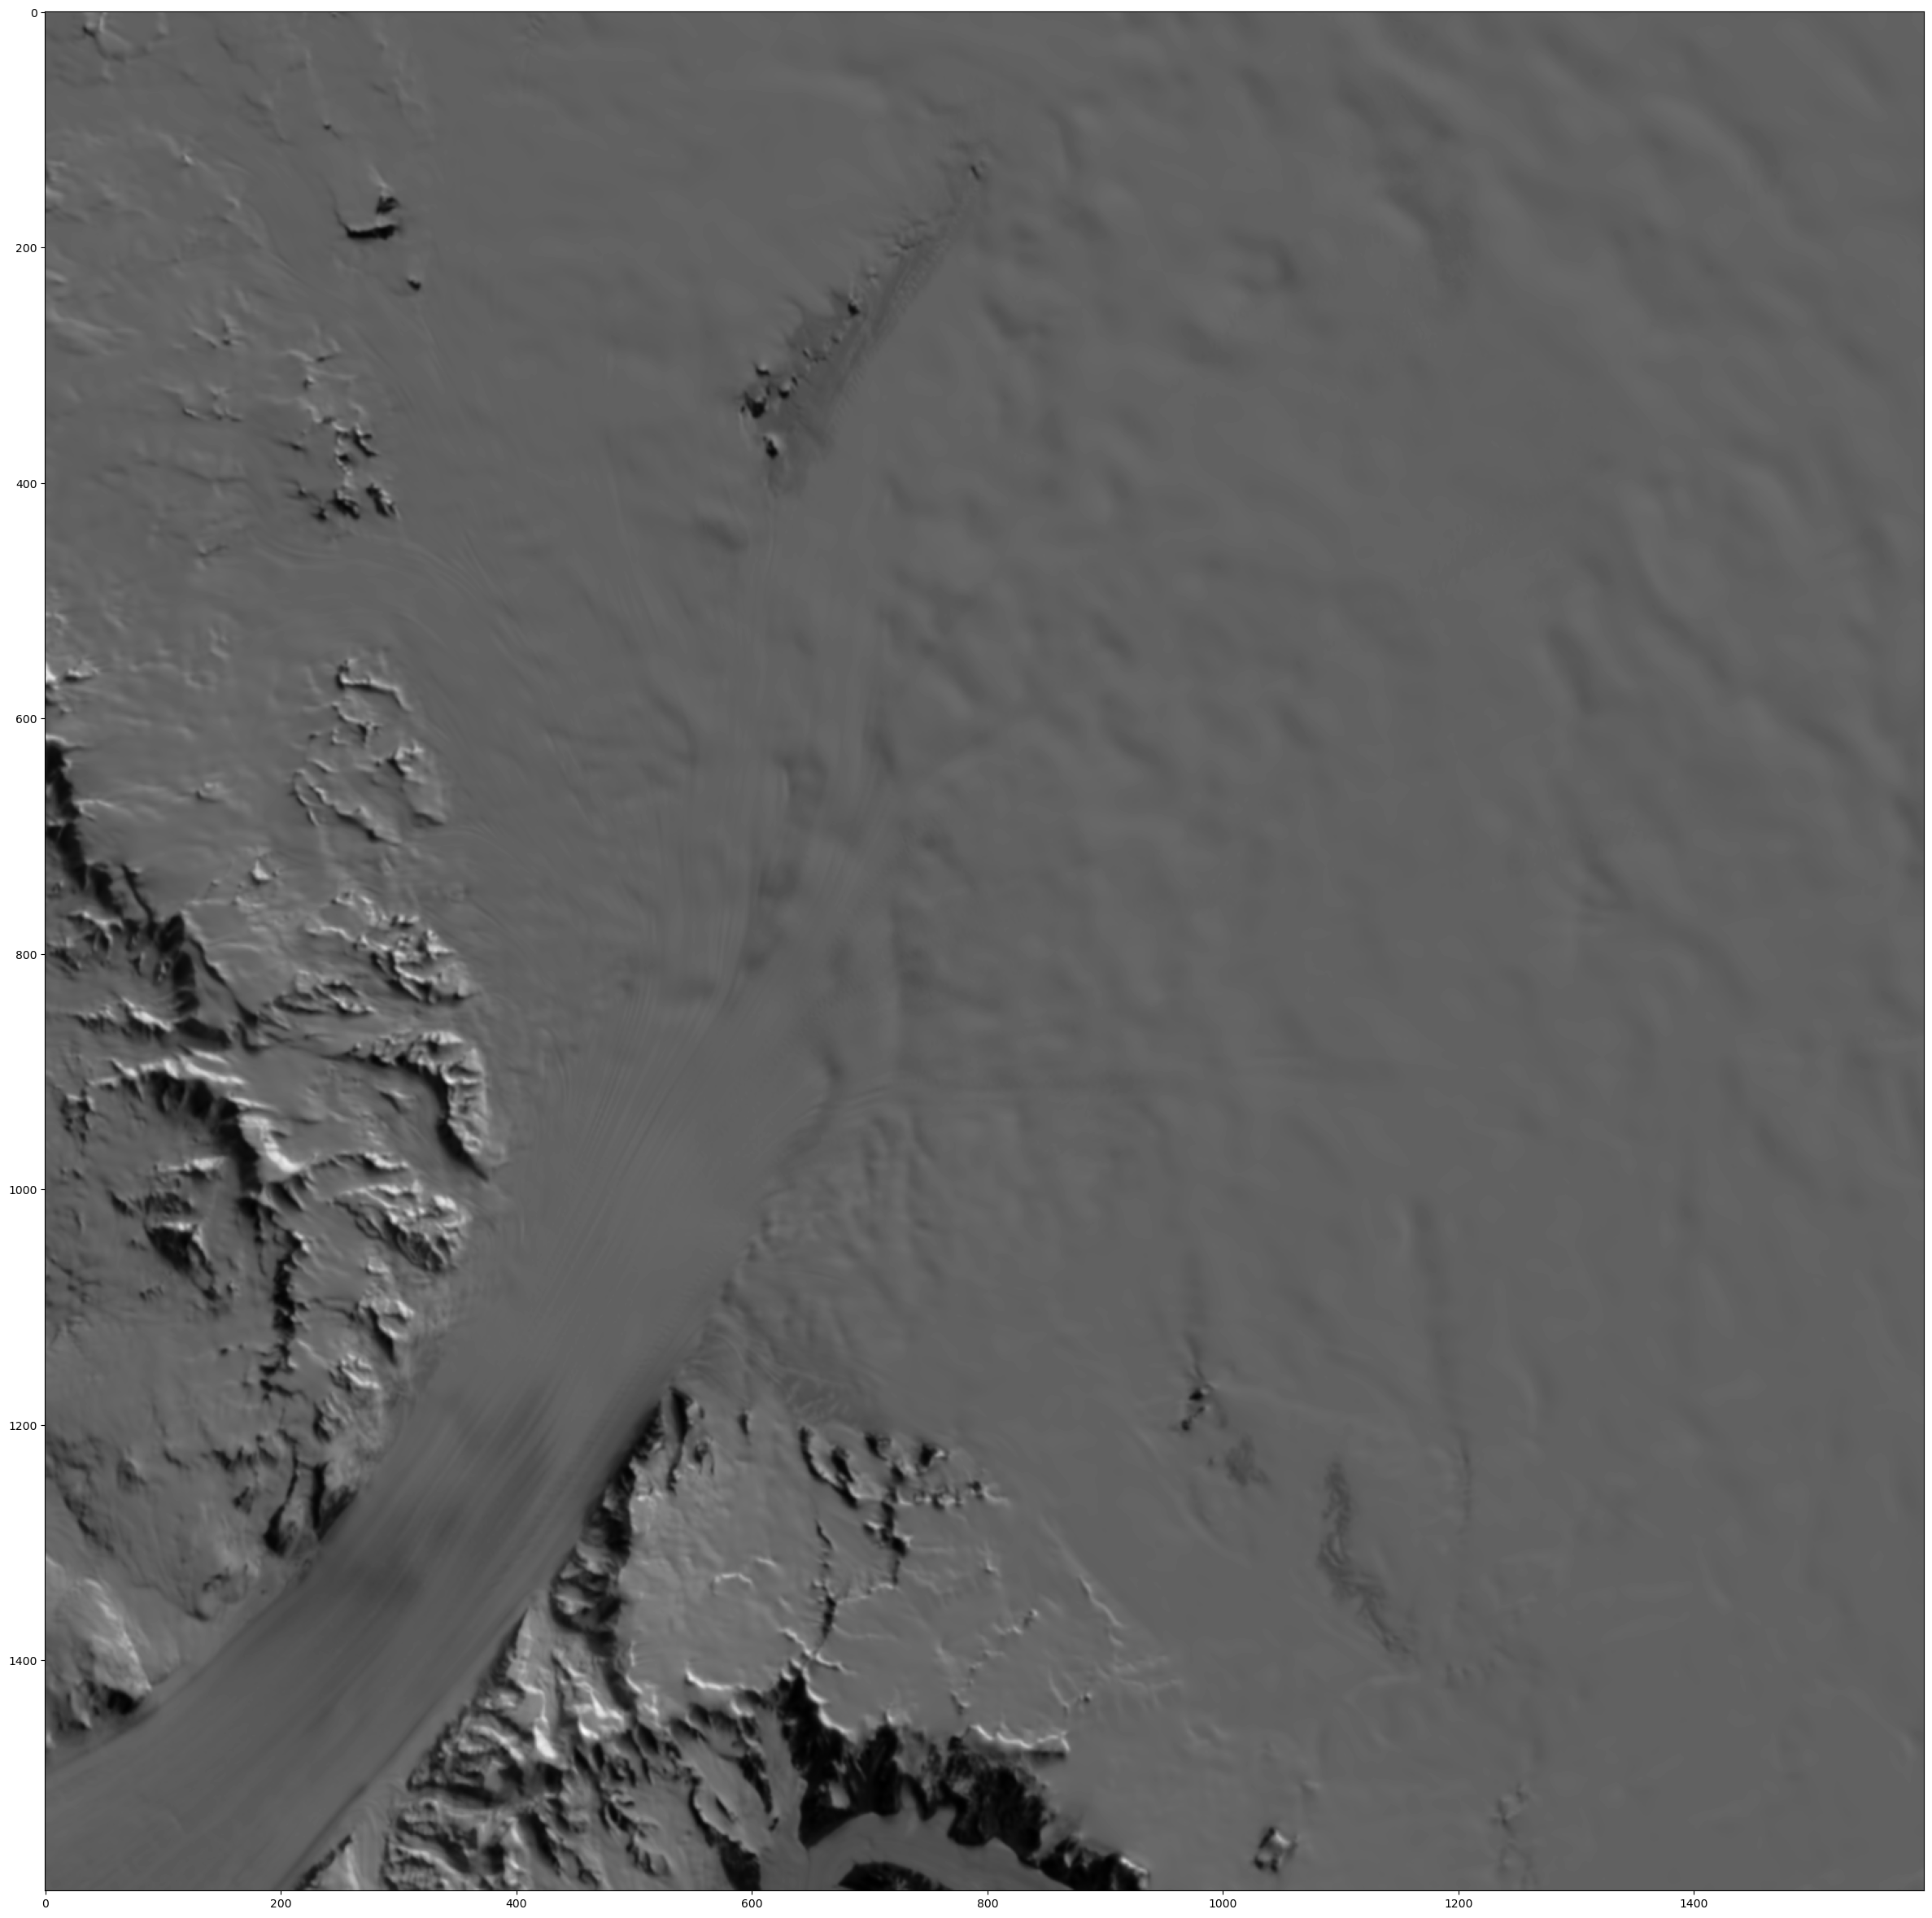

In [100]:
plt.figure(figsize = (30, 30))
plt.imshow(image_hr[y_min_125:y_max_125, x_min_125:x_max_125], cmap = 'gray')

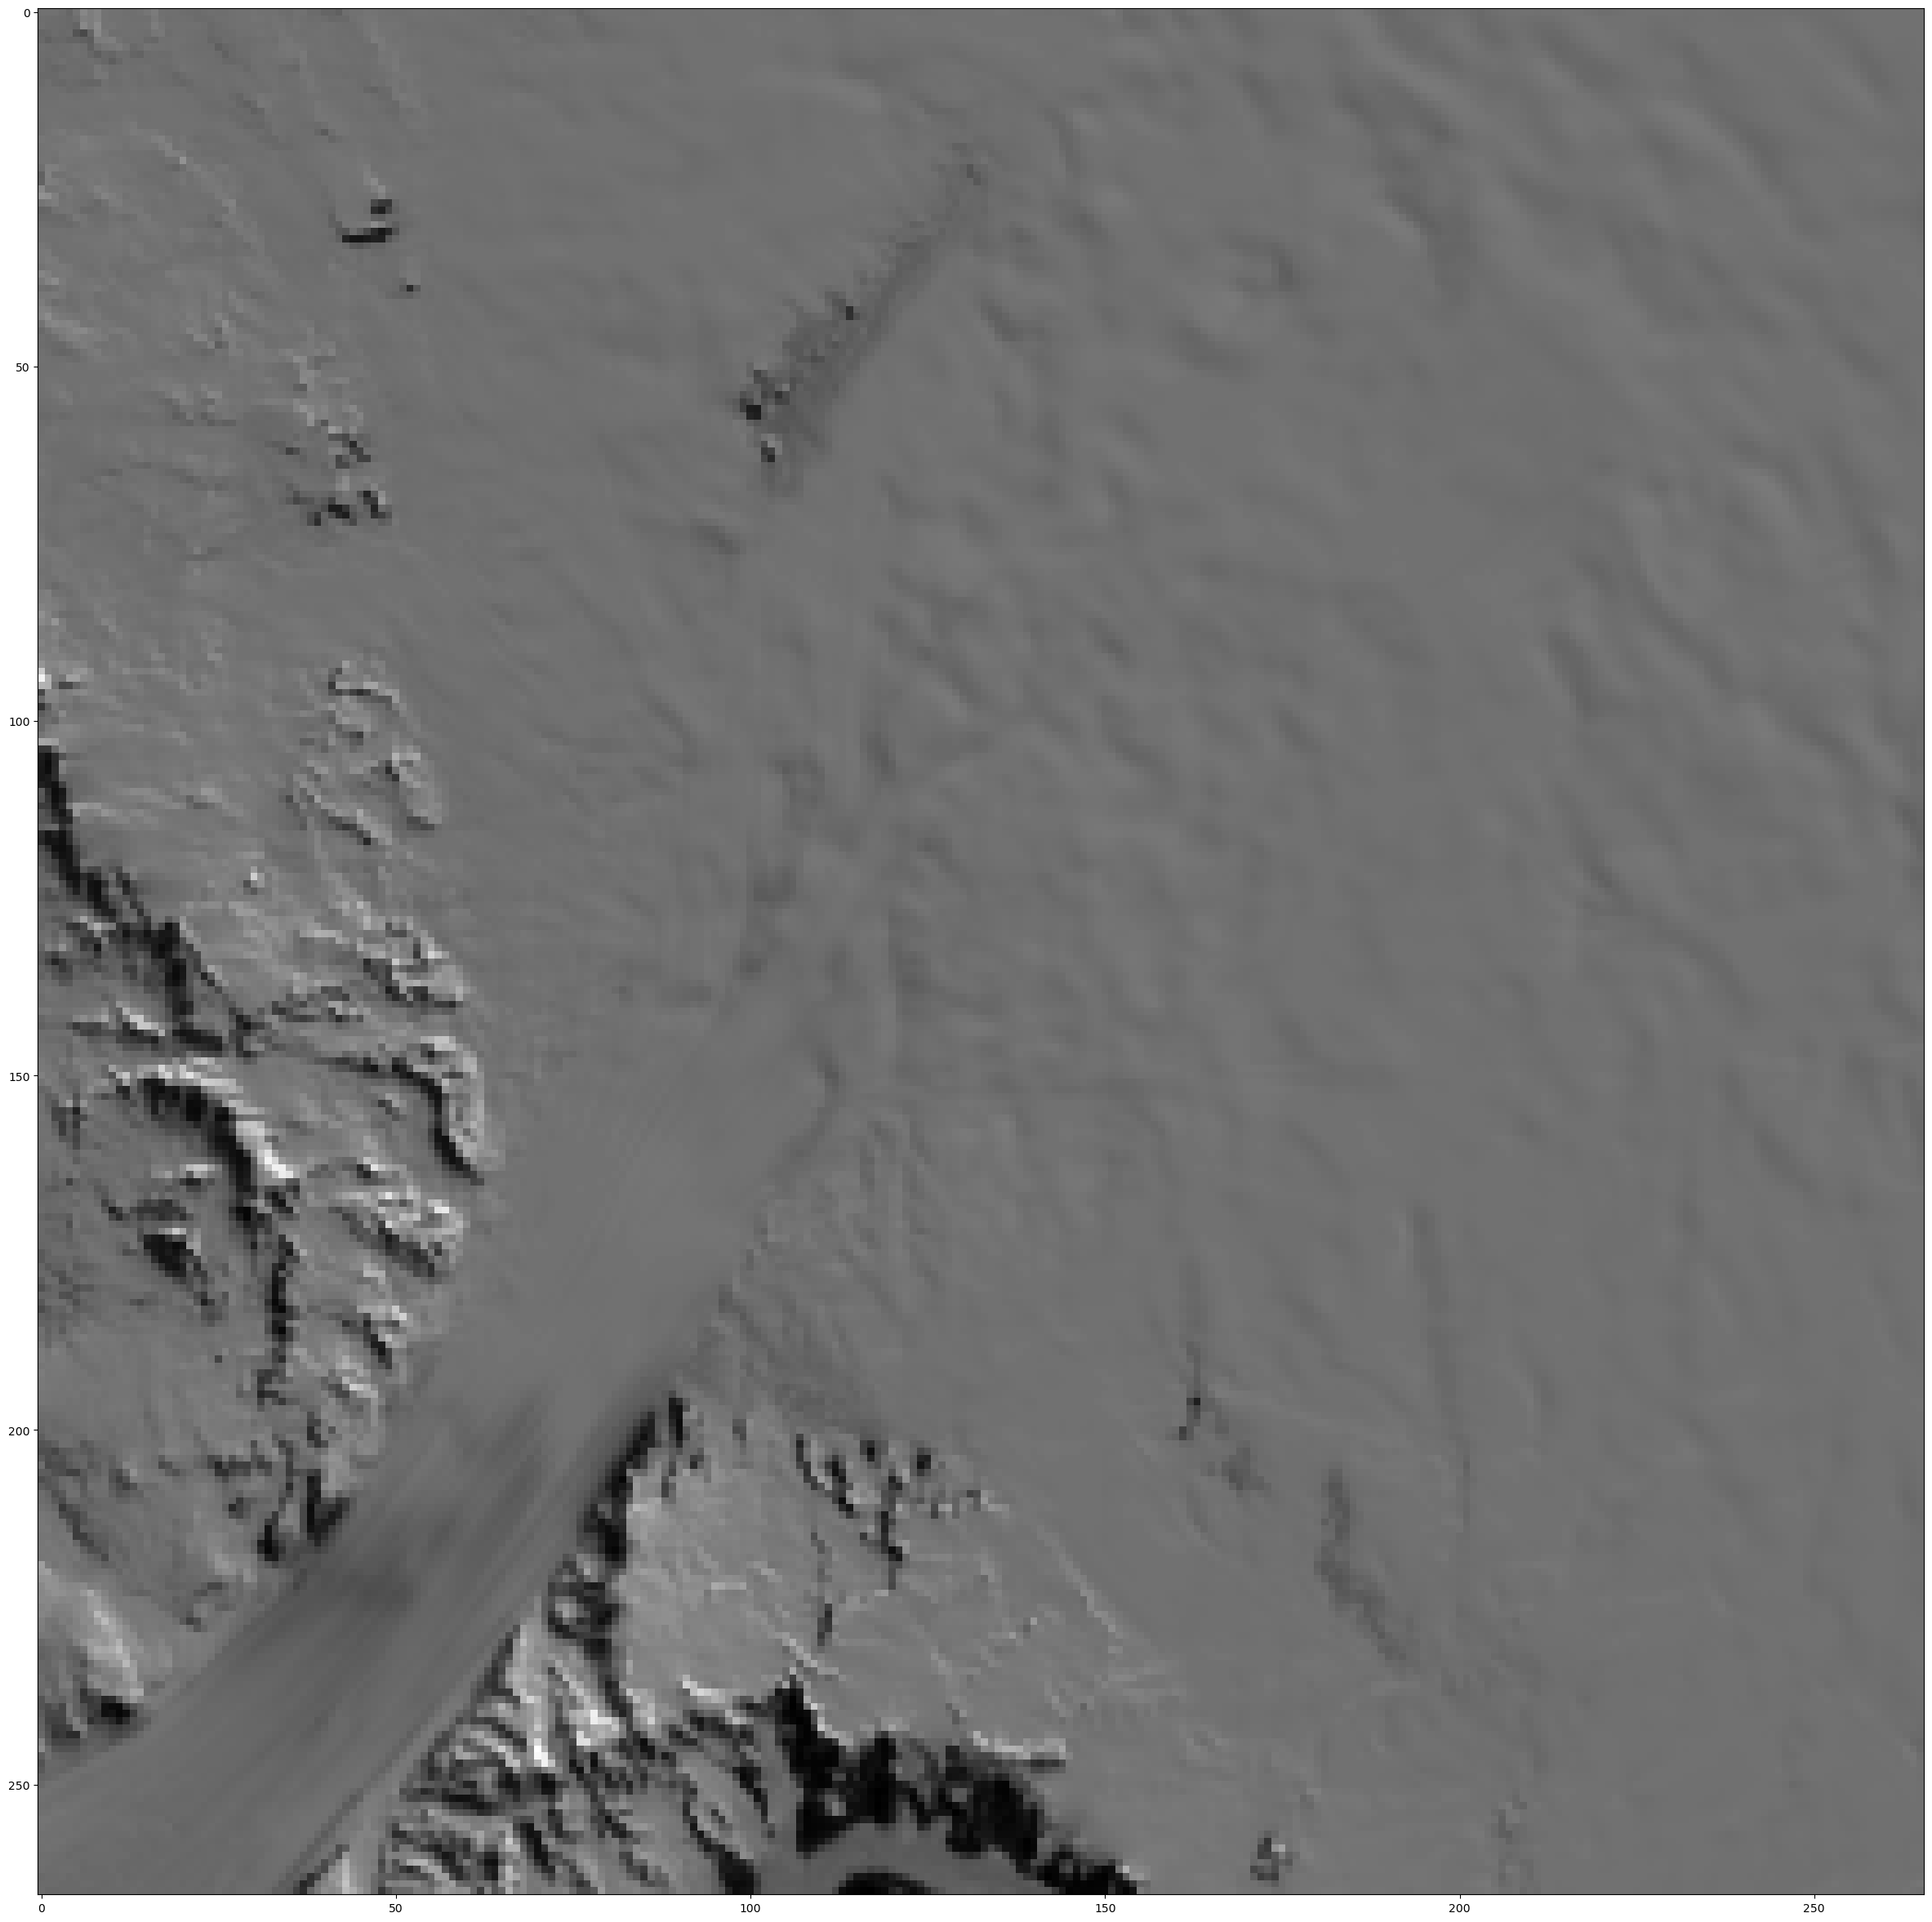

In [ ]:
plt.figure(figsize = (30, 30))
plt.imshow(image[y_min:y_max, x_min:x_max], cmap = 'gray')

# Save as pt file

In [ ]:
image_byrd = image[y_min:y_max, x_min:x_max]
image_byrd_float = image_byrd.astype(float)

torch.save(torch.tensor(image_byrd_float), 'data/moa750_2014_hp1_v01_byrd.pt')

image_byrd_hr = image_hr[y_min_125:y_max_125, x_min_125:x_max_125]
image_byrd_hr_float = image_byrd_hr.astype(float)

torch.save(torch.tensor(image_byrd_hr_float), 'data_tif/moa125_2014_hp1_v01_byrd.pt')

# Experiment with coloring

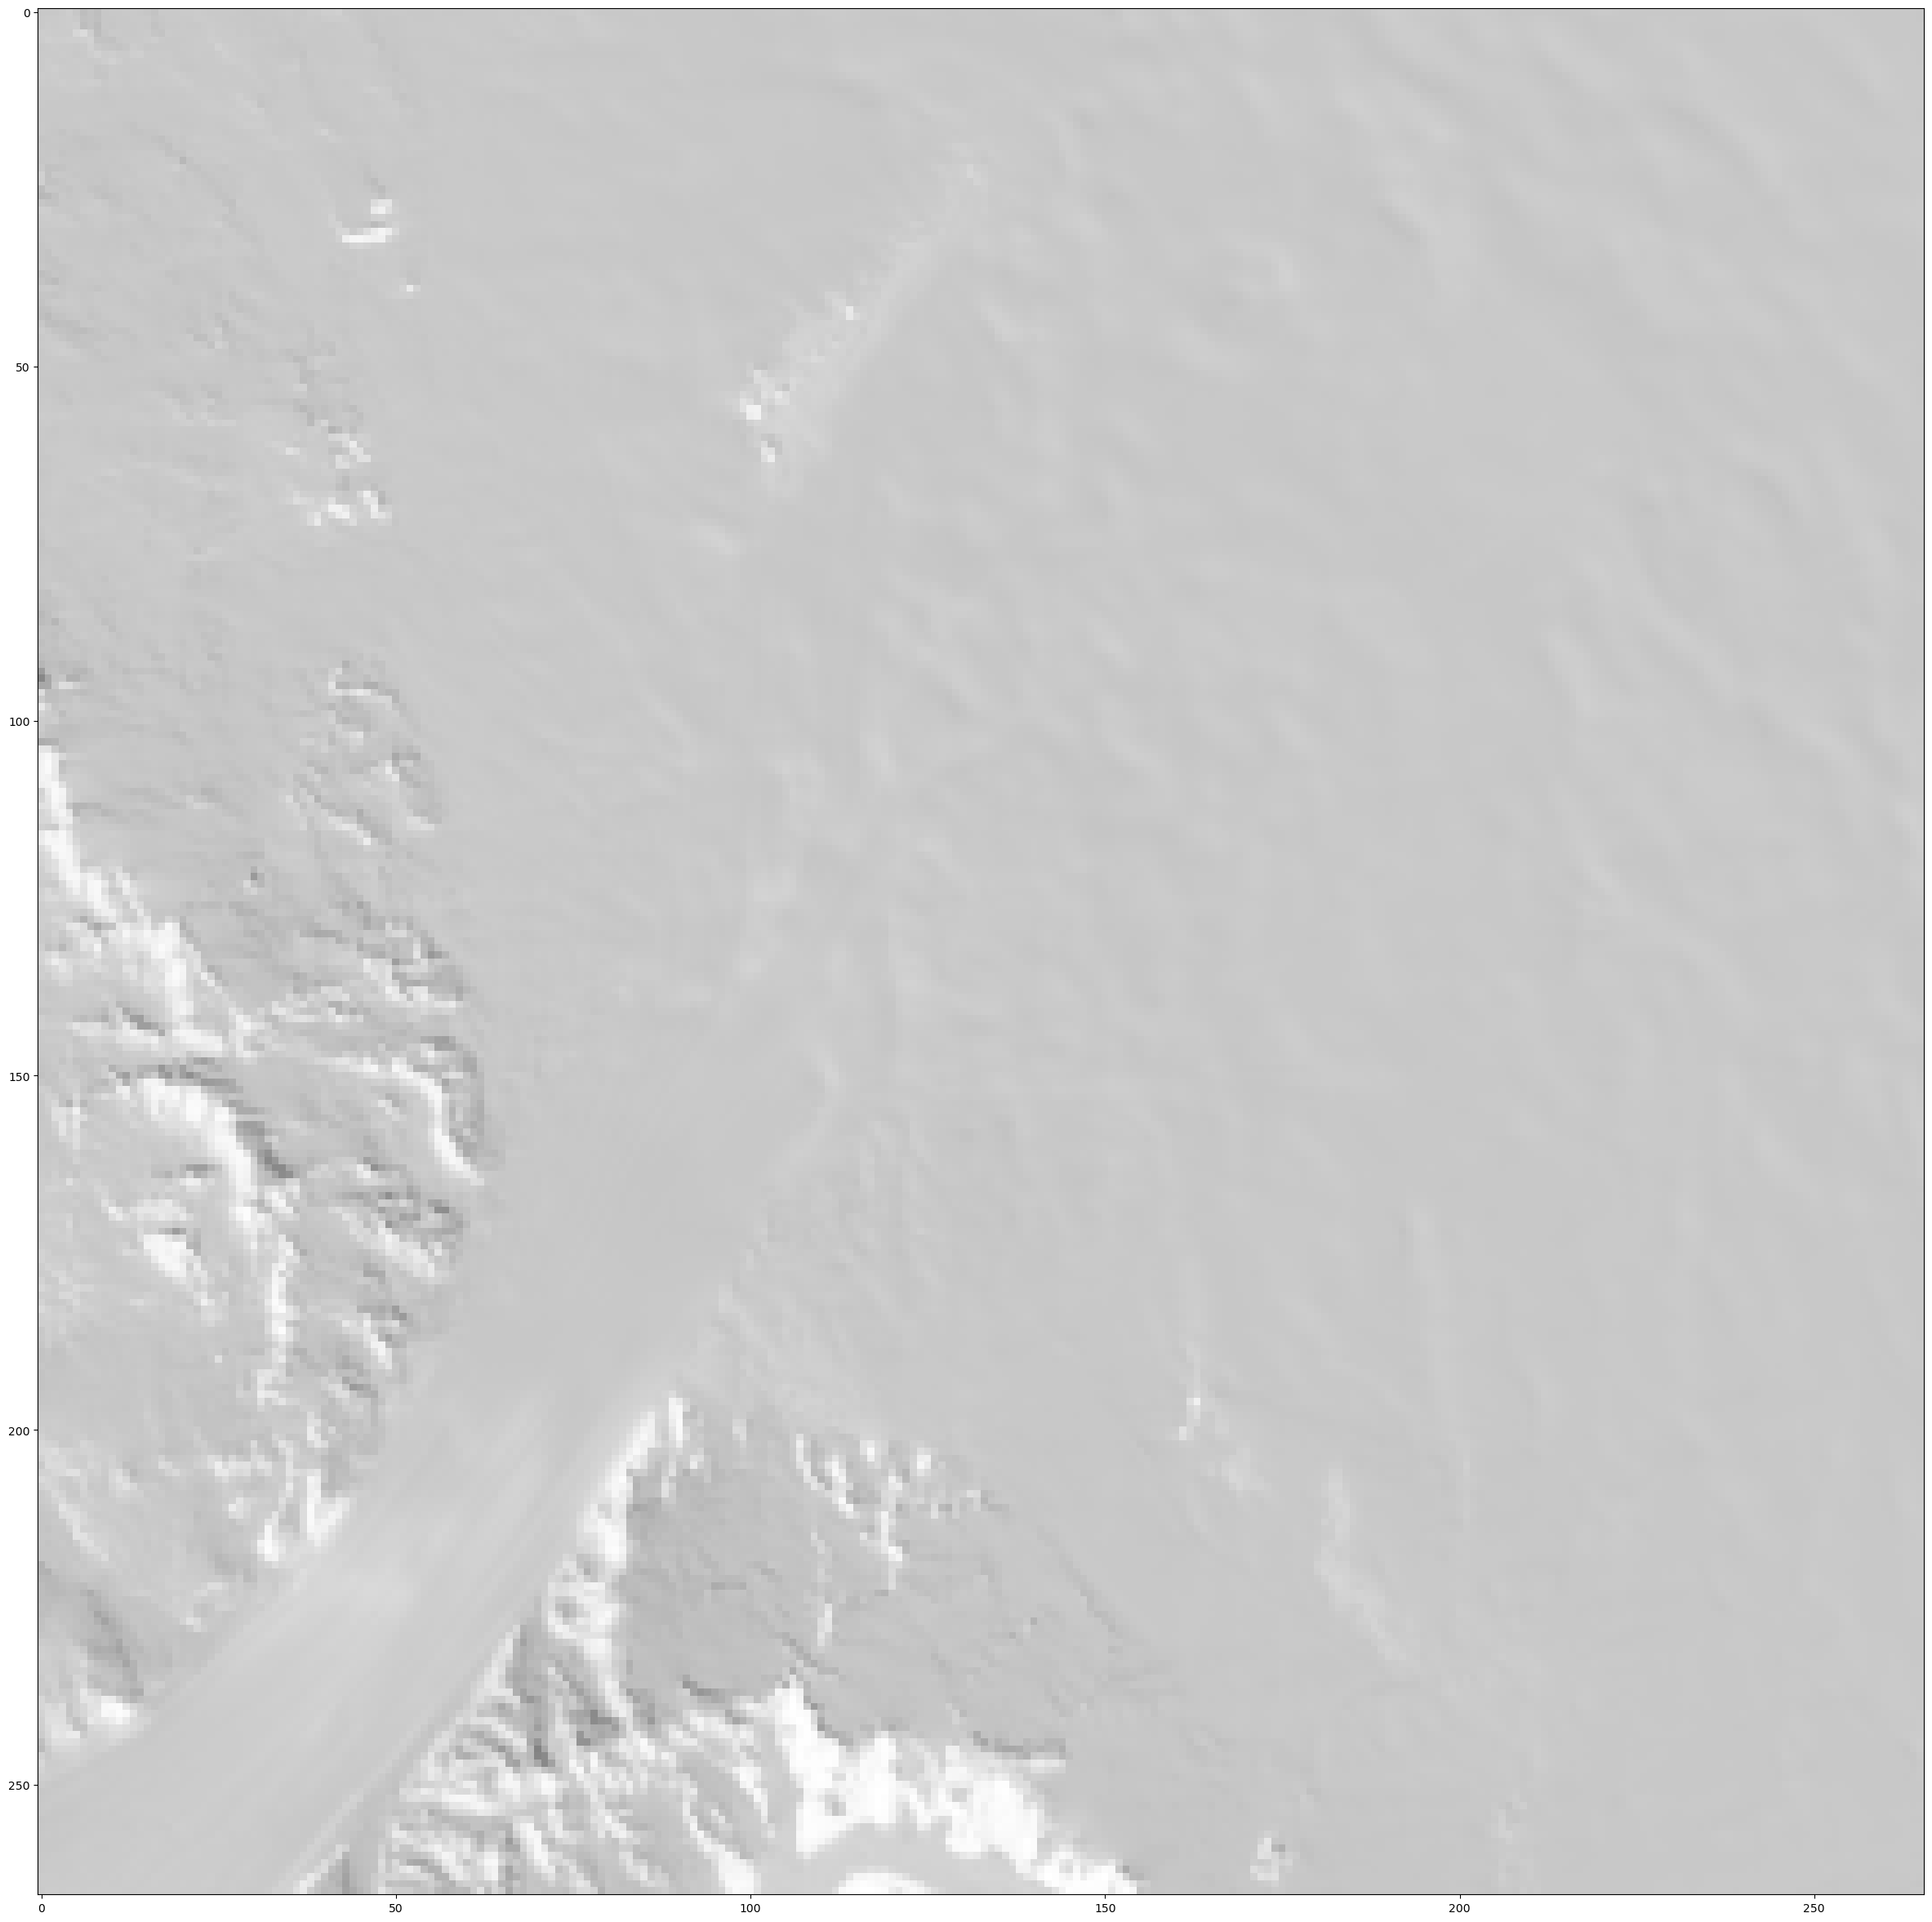

In [ ]:
print(image_byrd.min())
print(image_byrd.max())

plt.figure(figsize = (30, 30))
plt.imshow(image_byrd, cmap = 'binary', vmin = image_byrd.min(), vmax = image_byrd.max() * 2)